In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [8]:
data = pd.read_csv(r"C:\Users\user\Desktop\final Ai csv\pipline3.csv") 

In [9]:
data = data.drop(columns=["Unnamed: 0"])

In [10]:
X = data.drop(columns=["diabetes"])
y = data["diabetes"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [13]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)

In [14]:
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs'],
    'penalty': ['l2']
}

In [15]:
grid_search = GridSearchCV(log_reg, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)


GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000, random_state=42),
             n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10], 'penalty': ['l2'],
                         'solver': ['liblinear', 'lbfgs']},
             scoring='f1')

In [16]:
best_model = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)


Best Parameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}


In [17]:
y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

In [19]:
print("\n--- Model Evaluation ---")



--- Model Evaluation ---


In [22]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8815207780725022
Precision: 0.8864994026284349
Recall: 0.875
F1 Score: 0.8807121661721068
ROC-AUC: 0.9604591482193883

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.89      0.88      1697
           1       0.89      0.88      0.88      1696

    accuracy                           0.88      3393
   macro avg       0.88      0.88      0.88      3393
weighted avg       0.88      0.88      0.88      3393



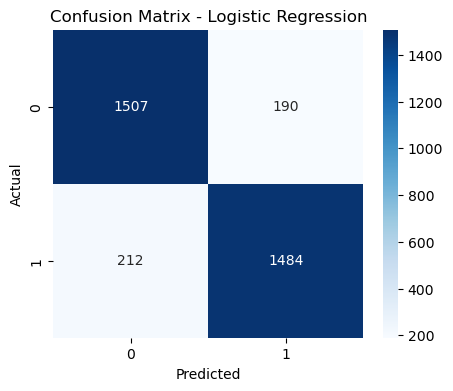

In [23]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [24]:
cv_scores = cross_val_score(best_model, X_train_scaled, y_train, cv=5, scoring='accuracy')
print("\nCross-validation Accuracy:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())



Cross-validation Accuracy: [0.87550645 0.89609433 0.88651437 0.88614591 0.88688283]
Mean CV Accuracy: 0.8862287762383438


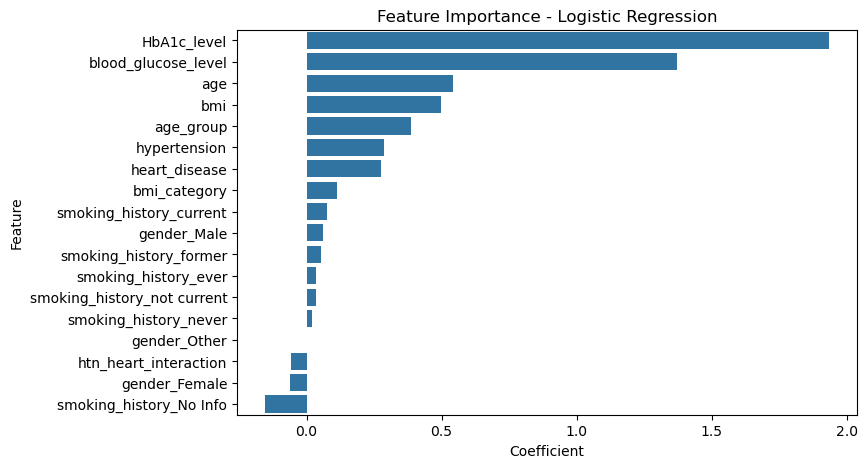

In [25]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(data=importance, x='Coefficient', y='Feature')
plt.title("Feature Importance - Logistic Regression")
plt.show()